### MUQ Beam

In [ ]:
def muq_beam(level, x): # https://um-bridge-benchmarks.readthedocs.io/en/docs/forward-benchmarks/muq-beam-propagation.html
    # docker run -it -p 4243:4243 linusseelinger/benchmark-muq-beam-propagation:latest
    assert level in [0]
    true_measure = qp.Uniform(qp.IIDStdUniform(3),lower_bound=1,upper_bound=1.05)
    um_bridge_model = umbridge.HTTPModel('http://localhost:4243','forward')
    um_bridge_config = {}
    integrand = qp.UMBridgeWrapper(true_measure,um_bridge_model,um_bridge_config,parallel=10)
    y = torch.from_numpy(integrand.f(x.numpy()))
    return y
if False: # set to True to generate MUQ data
    dseq = qp.DigitalNetB2(3,randomize="DS",seed=7)
    x = torch.from_numpy(dseq(2**15))
    y = muq_beam(0,x)
    muq_data = {"x":x,"y":y}
    print(muq_data)
    torch.save(muq_data,"./muq_data.pt")

### Advection Equation 

https://github.com/MatthieuDarcy/KernelsOperatorLearning/blob/main/LowDataRegime/Advection%20equation%20I/Advection%20equation.ipynb

https://github.com/lu-group/deeponet-fno/blob/main/data/advection/advection.py

In [ ]:
class Advection:
    def __init__(self, height, width, c, xm, xa, xb):
        """PBC"""
        self.h = height  # height
        self.w = width  # width
        self.xm = xm  # center location
        self.c = c  # velocity
        self.xa = xa  # Left domain point
        self.xb = xb  # right domain point

    def solve(self, X):
        x = X[:, 0:1]
        t = X[:, 1:2]
        n = np.shape(x)[0]
        u = np.zeros_like(x)
        h = self.h
        w = self.w
        c = self.c
        xm = self.xm
        xa = self.xa
        xb = self.xb
        for i in range(n):
            na = (xm - w / 2.0 + c * t[i, 0] - xa) // (xb - xa)
            nb = (xm + w / 2.0 + c * t[i, 0] - xa) // (xb - xa)
            xl = xa + (xm - w / 2.0 + c * t[i, 0] - xa) - na * (xb - xa)
            xr = xa + (xm + w / 2.0 + c * t[i, 0] - xa) - nb * (xb - xa)
            if xl < xr:
                if x[i, 0] >= xl and x[i, 0] <= xr:
                    u[i, 0] = h
                else:
                    u[i, 0] = 0.0
            else:
                if x[i, 0] >= xl or x[i, 0] <= xr:
                    u[i, 0] = h
                else:
                    u[i, 0] = 0.0
        # for i in range(n):
        #    if (x[i,0]-c*t[i,0]>=xm-w/2.0 and x[i,0]-c*t[i,0]<=xm+w/2.0):
        #        u[i,0] = h
        #    else:
        #        u[i,0] = 0.0
        return u


class Advection_v2:
    def __init__(self, x0, x1, c1, w, h1, c2, a, h2):
        self.x0 = x0
        self.x1 = x1
        self.c1 = c1
        self.w = w
        self.h1 = h1
        self.c2 = c2
        self.a = a
        self.h2 = h2

    def solve(self, X):
        x = X[:, 0:1] - X[:, 1:2]
        dx = x - self.x0
        n = dx // (self.x1 - self.x0)
        x -= n * (self.x1 - self.x0)

        xl = self.c1 - self.w / 2
        xr = self.c1 + self.w / 2
        u1 = self.h1 * np.heaviside(x - xl, 0.5) * np.heaviside(xr - x, 0.5)
        u2 = np.sqrt(np.maximum(self.h2 ** 2 - self.a ** 2 * (x - self.c2) ** 2, 0))
        return u1 + u2

if False:
    import deepxde as dde
    nx = 40
    nt = 40
    geom = dde.geometry.Interval(0, 1)
    timedomain = dde.geometry.TimeDomain(0, 1)
    geomtime = dde.geometry.GeometryXTime(geom, timedomain)
    x = geomtime.uniform_points(nx * nt, boundary=True)

    z = qp.DigitalNetB2(dimension=6,randomize="DS",seed=7)(2**13)
    u1 = []
    u2 = []
    for i in range(z.shape[0]):
        pde1 = Advection(
            height = z[i,0] + 1,  # [1, 2] 
            width = 0.3 * z[i,1] + 0.3,  # [0.3, 0.6],
            c = 1,
            xm = 0.4 * z[i,2] + 0.3,  # x0, [0.3, 0.7]
            xa = 0,
            xb = 1)
        pde2 = Advection_v2(
            x0 = 0,
            x1 = 1,
            c1 = 0.1 * z[i,0] + 0.2,  # [0.2, 0.3]
            w = 0.1 * z[i,1] + 0.1,  # [0.1, 0.2]
            h1 = 1.5 * z[i,2] + 0.5,  # [0.5, 2]
            c2 = 0.1 * z[i,3] + 0.7,  # [0.7, 0.8]
            a = 5 * z[i,4] + 5,  # 1 / [0.1, 0.2] = [5, 10]
            h2 = 1.5 * z[i,5] + 0.5)  # [0.5, 2]
        u1.append(pde1.solve(x).reshape(nt, nx))
        u2.append(pde2.solve(x).reshape(nt, nx))
    u1 = np.array(u1)
    u2 = np.array(u2)
    data = {"x1":torch.from_numpy(z[:,:3]),"y1":torch.from_numpy(u1[:,nt//2,:]).T,"x2":torch.from_numpy(z),"y2":torch.from_numpy(u2[:,nt//2,:]).T}
    torch.save(data,"./advection.pt")


In [ ]:
adv_data = torch.load("./advection.pt")
# x_adv = adv_data["x1"]
# y_adv = adv_data["y1"]
x_adv = adv_data["x2"]
y_adv = adv_data["y2"]
def adv_pregen(level, x):
    assert 0<=level<40
    x_data = x_adv[:x.size(0)]
    y_data = y_adv[:,:x.size(0)]
    assert (x_data==x).all()
    return y_data[level]
x_adv_test = x_adv[-2**8:]
y_adv_test = y_adv[:,-2**8:]
times,yhatts,muhats,sigmahats = fit_gps(
    func = adv_pregen,
    d = x_adv.shape[-1], 
    levelops = [i for i in range(40)],
    n = 2**10*torch.ones(40,dtype=int),
    iterations = 50,
    xtest = x_adv_test,
    fit_std_gp = True,
    fit_gpytorch_gp = True, 
    fit_fgpdnet = True, 
    fit_fgplat = False,
    requires_grad_noise = True, 
    seeds = [7 for i in range(40)],
    rank = 5, 
    sgp_threshold = 2**14, 
    gpt_threshold = 2**14,
    verbose = 5, 
    predlevels = [i for i in range(40)],
    compute_muhats = True,
    compute_sigmahats = False,
    n_gp = 2**7*torch.ones(40,dtype=int),
    n_gpt = 2**7*torch.ones(40,dtype=int),
    n_fgpdnet = 2**7*torch.ones(40,dtype=int),
    n_fgplat = None,)
print("times:",times)
print(yhatts.shape)
print(muhats.shape)
# print(sigmahats.shape)

     iter of 5.0e+01 | best loss  | loss      
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
            0.00e+00 | 2.52e+04   | 2.52e+04  
            5.00e+00 | 4.72e+02   | 4.72e+02  
            1.00e+01 | -1.35e+03  | -1.35e+03 
            1.50e+01 | -2.43e+03  | -2.43e+03 
            2.00e+01 | -3.19e+03  | -3.19e+03 
            2.50e+01 | -4.61e+03  | -4.61e+03 
            3.00e+01 | -5.59e+03  | -5.59e+03 
            3.50e+01 | -6.44e+03  | -6.44e+03 
            4.00e+01 | -8.05e+03  | -8.05e+03 
            4.50e+01 | -8.27e+03  | -8.27e+03 
            5.00e+01 | -9.01e+03  | -9.01e+03 
iter: 0       GPT loss: 1.80e-01
iter: 5       GPT loss: 6.47e-02
iter: 10      GPT loss: -6.73e-02
iter: 15      GPT loss: -2.63e-01
iter: 20      GPT loss: 6.69e-01
iter: 25      GPT loss: -2.24e-01
iter: 30      GPT loss: 6.55e-01
iter: 35      GPT loss: 6.28e-01
iter: 40      GPT loss: 3.04e-01
iter: 45      GPT loss: 4.46e-01
iter: 49      GPT loss: -9.38e-02
     iter of 5.0e+01 |

mean L2 relative errors: tensor([0.3217, 0.7101, 0.3234])


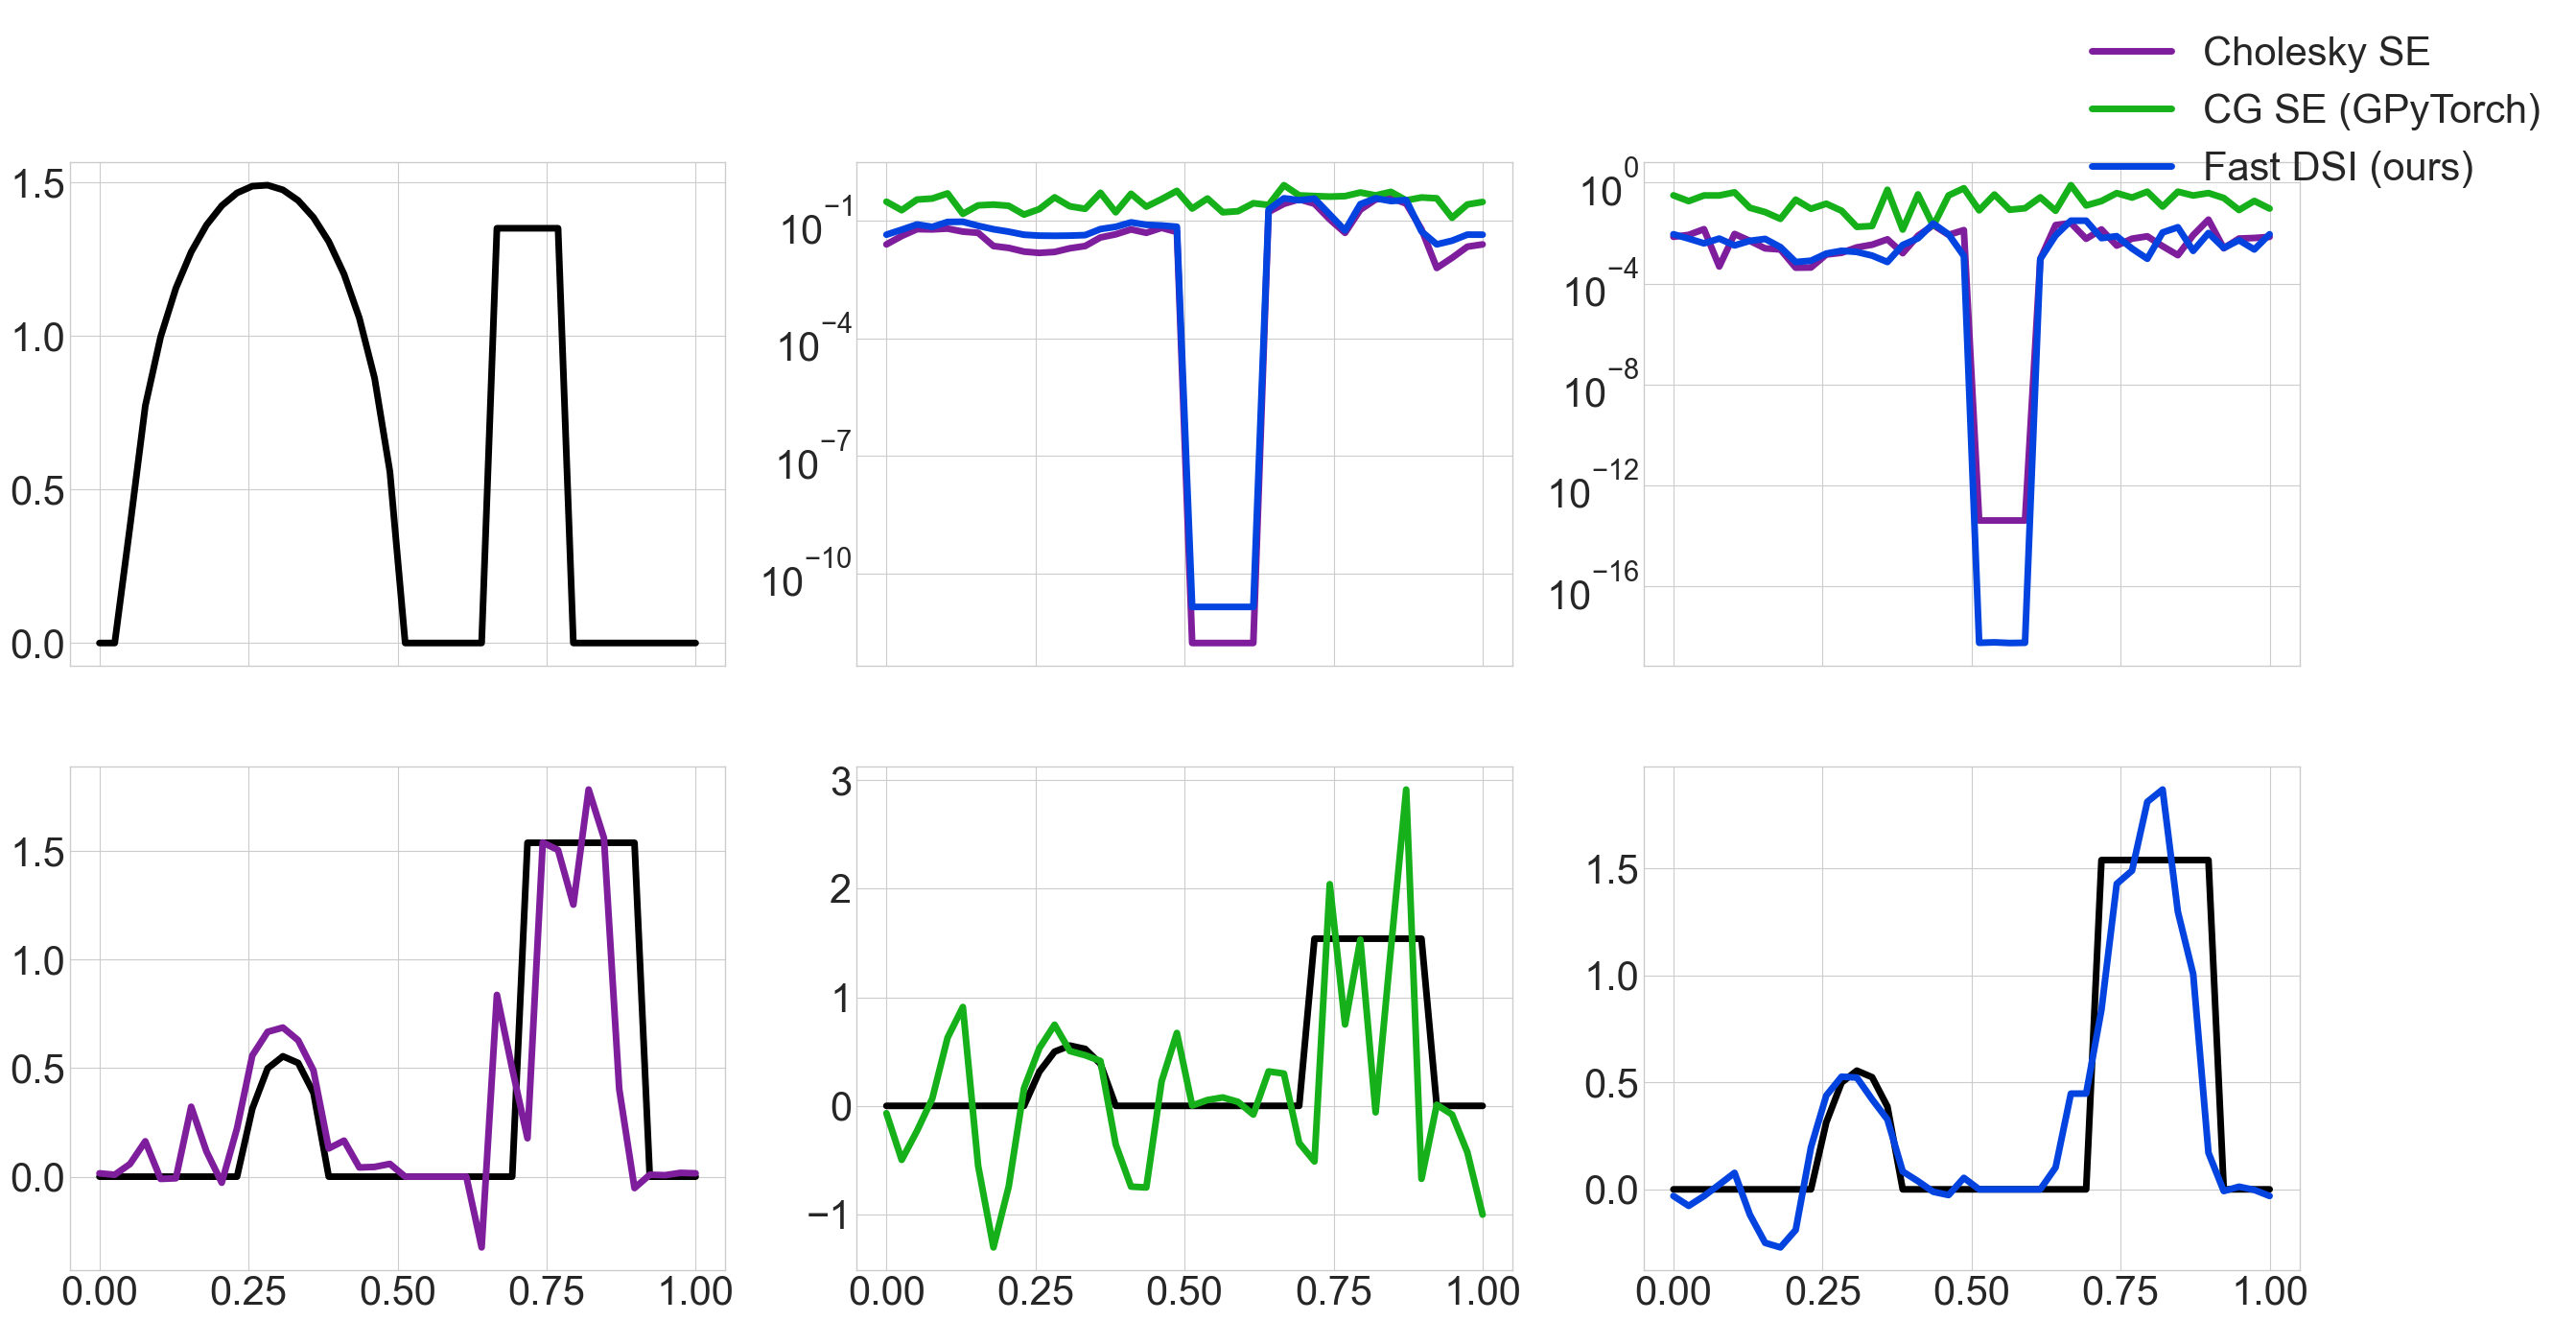

In [ ]:
with np.printoptions(formatter={"float":lambda x: "%.1e"%x}):
    print("mean L2 relative errors: %s"%str((torch.linalg.norm(y_adv_test-yhatts,dim=-2)/torch.linalg.norm(y_adv_test,dim=-2)).mean(-1)))
ALPHA = 0.25
LW = .1
gp_names = ["Cholesky SE","CG SE (GPyTorch)","Fast DSI (ours)"]
xticks = torch.linspace(0,1,40)
fig,ax = pyplot.subplots(nrows=2,ncols=3,figsize=(PW,PW*2/4),sharex=True,sharey=False)
R = 7
ax[0,0].plot(xticks,y_adv_test[:,:2**0],color='k')#,linewidth=LW)
for i in range(3):
    ax[0,1].plot(xticks,torch.abs(y_adv_test-yhatts[i]).median(-1).values,color=COLORS[i])
    ax[0,2].plot(xticks,torch.abs(y_adv.mean(-1)-muhats[i]),label=gp_names[i],color=COLORS[i])
    ax[1,i].plot(xticks,y_adv_test[:,R],color='k')
    ax[1,i].plot(xticks,yhatts[i,:,R],color=COLORS[i])
    # ax[1,i].fill_between(xticks,yhatts[i,:,R]-sigmahats[i,:,R],yhatts[i,:,R]+sigmahats[i,:,R],color=COLORS[i],alpha=ALPHA)
ax[0,1].set_yscale("log",base=10)
ax[0,2].set_yscale("log",base=10)
fig.legend();
# ax[1,0].set_yscale("log",base=10)

### MUQ Beam

In [ ]:
muq_data = torch.load("./muq_data.pt")
x_muq = muq_data["x"]
y_muq = muq_data["y"]
def muq_pregen(level, x):
    assert 0<=level<31
    x_data = x_muq[:x.size(0)]
    y_data = y_muq[:,:x.size(0)]
    assert (x_data==x).all()
    return y_data[level]
x_muq_test = x_muq[-2**8:]
y_muq_test = y_muq[:,-2**8:]
times,yhatts,muhats,sigmahats = fit_gps(
    func = muq_pregen,
    d = 3, 
    levelops = [i for i in range(31)],
    n = 2**10*torch.ones(31,dtype=int),
    iterations = 50,
    xtest = x_muq_test,
    fit_std_gp = True,
    fit_gpytorch_gp = True, 
    fit_fgpdnet = True, 
    fit_fgplat = False,
    requires_grad_noise = False, 
    seeds = [7 for i in range(31)],
    rank = 31, 
    sgp_threshold = 2**12, 
    gpt_threshold = 2**12,
    verbose = 5, 
    predlevels = [i for i in range(31)],
    compute_muhats = True,
    compute_sigmahats = False,
    n_gp = 2**5*torch.ones(31,dtype=int),
    n_gpt = 2**5*torch.ones(31,dtype=int),
    n_fgpdnet = 2**8*torch.ones(31,dtype=int),
    n_fgplat = None,)
print("times:",times)
print(yhatts.shape) 
print(muhats.shape) 
# print(sigmahats.shape) 

torch.Size([32768, 3]) torch.Size([31, 32768])


AssertionError: 

In [ ]:
ALPHA = 0.25
LW = .1
gp_names = ["Cholesky SE","CG SE (GPyTorch)","Fast DSI (ours)"]
xticks = torch.arange(31)
fig,ax = pyplot.subplots(nrows=1,ncols=4,figsize=(PW,PW/4),sharex=True,sharey=False)
R = 0
for i in range(3):
    ax[0].plot(xticks,y_muq_test[:,:2**7],color='k',linewidth=LW)
    ax[2].plot(xticks[1:],torch.abs(y_muq_test-yhatts[i]).median(-1).values[1:])
    ax[3].plot(xticks[1:],torch.abs(y_muq_test.mean(-1)-muhats[i])[1:],label=gp_names[i])
ax[2].set_yscale("log",base=10)
ax[3].set_yscale("log",base=10)
fig.legend();
# ax[1,0].set_yscale("log",base=10)